## Import the dependencies

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load and inspect the dataset

In [ ]:
cc_df = pd.read_csv('../data/raw/creditcard.csv')

In [ ]:
print(cc_df.shape)
print(cc_df.head())
print(cc_df.info())

# 2. Data cleaning

### 2.1. Missing value checks

In [ ]:
print(cc_df.isnull().sum())

### 2.2. Duplicates and Data Types

In [ ]:
print(cc_df.dtypes)

In [ ]:
# Duplicates
print("Duplicated rows: ", cc_df.duplicated().sum())

In [ ]:
cc_df = cc_df.drop_duplicates()
print(cc_df.info)

# 3. Exploratory Data Analysis (EDA)

## 3.1 Univariate Analysis

In [ ]:
print(cc_df['Amount'].describe())

In [ ]:
print(cc_df['Amount'].describe())
print("The median is: " , cc_df['Amount'].median())
sns.histplot(cc_df['Amount'], bins=50)
plt.title('Transaction Amount Distribution')
plt.show()

Since there seems like to be an outlier in this dataset I want to draw a box plot.

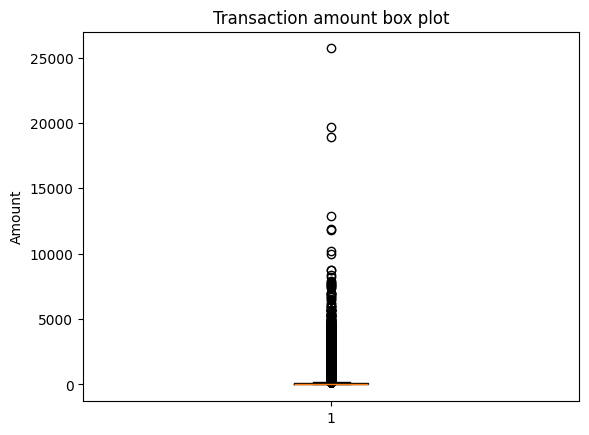

In [16]:
# I have to do a box plot analysis to look more in to the disperssion of the Amount column
plt.boxplot(cc_df['Amount'])
plt.title("Transaction amount box plot")
plt.ylabel("Amount")
plt.show()

This is exactly the kind of distribution where a plain StandardScaler can be misleading — a few extreme values in the tail can dominate the mean/std calculation, distorting the scale for the bulk of "normal" transactions. This is a strong candidate for a log transform (np.log1p(Amount)) before scaling, which compresses the tail and makes the bulk of the distribution easier for models to learn from.

## 3.2 Bivariate Analysis

In [15]:
print(cc_df['Amount'].value_counts())
print(cc_df['Amount'].value_counts(normalize=True) * 100)

Amount
1.00      13566
1.98       6044
0.89       4871
9.99       4738
15.00      3280
          ...  
301.34        1
614.00        1
279.79        1
615.52        1
180.93        1
Name: count, Length: 32767, dtype: int64
Amount
1.00      4.781374
1.98      2.130224
0.89      1.716797
9.99      1.669921
15.00     1.156045
            ...   
301.34    0.000352
614.00    0.000352
279.79    0.000352
615.52    0.000352
180.93    0.000352
Name: proportion, Length: 32767, dtype: float64


In [22]:
# Amount by Class
print(cc_df.groupby('Class')['Amount'].mean())
print(cc_df.groupby('Class')['Amount'].median())

Class
0     88.413575
1    123.871860
Name: Amount, dtype: float64
Class
0    22.00
1     9.82
Name: Amount, dtype: float64
